# Implementing ChemKAN — guided workbook

This is your **workspace**. Each milestone explains *why* each piece exists and
*why each parameter is there*, then leaves the actual code (the `# TODO`s) to you.
The answers are **not** here — they live in the companion guide
[`docs/implementing_chemkan_from_scratch.md`](../../docs/implementing_chemkan_from_scratch.md)
inside collapsible "Reference" blocks. Try first; peek only when stuck.

**How to work each milestone**
1. Read the intuition + "Why these parameters".
2. Fill in the `# TODO`s in the class cell.
3. Run the **check** cell — it must pass / produce the right plot.
4. Once it works, **paste your class into the matching `src/` module** (noted at
   the end of each milestone) so the later milestones can `import` it.

You'll implement Milestones 1–4 here (they're visual and interactive). Milestones
5–7 (the ChemKAN model + training) you build directly in the `src/` files, using
the same guide.

## Setup

In [1]:
# pip install torch torchdiffeq matplotlib   # (one time)
import sys, math
from pathlib import Path
import torch, torch.nn as nn
import matplotlib.pyplot as plt

# so you can import your promoted modules later:  from kan import RBFActivation, ...
SRC = Path.cwd().parents[0] / "src"          # chemkan/src  (adjust if needed)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("src on path:", SRC, "| exists:", SRC.exists())
print("torch:", torch.__version__)

src on path: /Users/berke/Desktop/University/TU_Wien-MSC/2026S/Interdisciplinary_Project/development/chemkan-tuwien/chemkan/src | exists: True
torch: 2.13.0


---
## Milestone 1 — one learnable function φ(x)  (Eq. 11–12)

**Intuition.** A KAN puts a learnable *function* on every edge. Here you build one:
a curve made of `N` Gaussian bumps whose heights are trainable. Raise a bump → the
curve lifts near that spot. Enough bumps → any smooth 1-D shape.

$$\phi_{l,\alpha,\beta}(x)=\sum_{i=1}^{N} w^{\psi}_{l,\alpha,\beta,i}\,\exp\!\Big(\!-\tfrac{\lVert x-c_i\rVert^2}{2h^2}\Big)+w^{b}_{l,\alpha,\beta}\,b(x)$$

**Why these parameters** (this is the part to really absorb):

| param | what it controls | why you need it |
|---|---|---|
| `num_basis` (N) | how many bumps | resolution/capacity of the curve; ↑ = wigglier fits but more params & overfit risk |
| `x_min, x_max` | where the bump centers `c_i` sit | must cover the input range, or every Gaussian ≈ 0 and the neuron is *dead* |
| `h` (spacing) | bump width | derived from the grid so bumps overlap smoothly; too narrow → gaps, too wide → can't localize |
| `w_rbf` | bump heights | **the learnable shape** — training moves these |
| `w_base`, `base` (SiLU) | residual path | gives a sensible nonzero start + clean gradients, so RBFs learn only the *residual* |

In [2]:
class RBFActivation(nn.Module):
    # One learnable univariate function phi(x)  (Eq. 11-12), single edge.
    def __init__(self, num_basis=10, x_min=-1.0, x_max=1.0):
        super().__init__()
        # TODO:
        #   centers = linspace(x_min, x_max, num_basis) -> register_buffer  (fixed)
        #   self.h  = (x_max - x_min) / (num_basis - 1)                      (bump width)
        #   self.w_rbf  = nn.Parameter, shape (num_basis,)                   (bump heights)
        #   self.w_base = nn.Parameter, shape (1,)
        #   self.base   = nn.SiLU()

        centers = torch.linspace(x_min, x_max, num_basis) # c_i
        self.register_buffer("centers", centers)

        self.h = (x_max - x_min) / (num_basis -1) # steps between grids
        # Learnable parameters
        self.w_rbf = nn.Parameter(torch.rand(num_basis) * 0.1) # w^psi , shape is (num_basis, )

        # residual path?
        self.w_base = nn.Parameter(torch.zeros(1)) # w^b
        self.base = nn.SiLU()

    def forward(self, x:torch.Tensor):                    # x: (batch,)
        # TODO:
        #   r   = x[:, None] - self.centers          # (batch, num_basis)
        #   psi = torch.exp(-r**2 / (2*self.h**2))   # Gaussian bumps (batch, num_basis)
        #   return psi @ self.w_rbf + self.w_base * self.base(x)
        
        # x[:, None]this is equal to x.unsqueeze(1) == x.unsqueeze(-1) == x[..., None] == x.reshape(-1, 1), it inserts a new col.

        r = x[:, None] - self.centers # this is x - c_i at numerator at the eq. 11 (batch,)
        psi = torch.exp(-r ** 2 / (2 * self.h**2)) # eq. 12 (batch, num_basis)
        
        return psi @ self.w_rbf + self.w_base * self.base(x)  # In paper "w * psi" is elementwise



**Check** — fit φ to a target and *look at it* (and its bumps):

In [3]:
torch.manual_seed(0)
phi = RBFActivation(num_basis=12)
opt = torch.optim.Adam(phi.parameters(), lr=0.05)
x = torch.linspace(-1, 1, 200); y = torch.sin(3*x)
for _ in range(2000):
    opt.zero_grad(); loss = ((phi(x) - y)**2).mean(); loss.backward(); opt.step()
print("final MSE:", loss.item(), " (want < 1e-3)")

plt.plot(x, y, "k", label="target sin(3x)")
plt.plot(x.detach(), phi(x).detach(), "r--", label="learned phi")
# see the decomposition: each bump height * gaussian
with torch.no_grad():
    r = x[:, None] - phi.centers
    bumps = torch.exp(-r**2/(2*phi.h**2)) * phi.w_rbf
for b in bumps.T:
    plt.plot(x, b, color="0.8", lw=0.8)
plt.legend(); plt.title("phi = sum of scaled Gaussian bumps"); plt.show()

final MSE: 1.357793098577531e-05  (want < 1e-3)


<Figure size 640x480 with 1 Axes>

### Watch it learn — bumps growing into φ

Same fit as above, but snapshotted at several steps so you can *see* the 12 grey Gaussian bumps stretch to different heights until their sum (red) traces `sin(3x)` (black). Training a KAN activation is literally just choosing these bump heights (`w_rbf`).

> Red φ = sum of the grey bumps **+** the small `w_base·SiLU(x)` residual, so the grey curves add up to *almost* the red one.

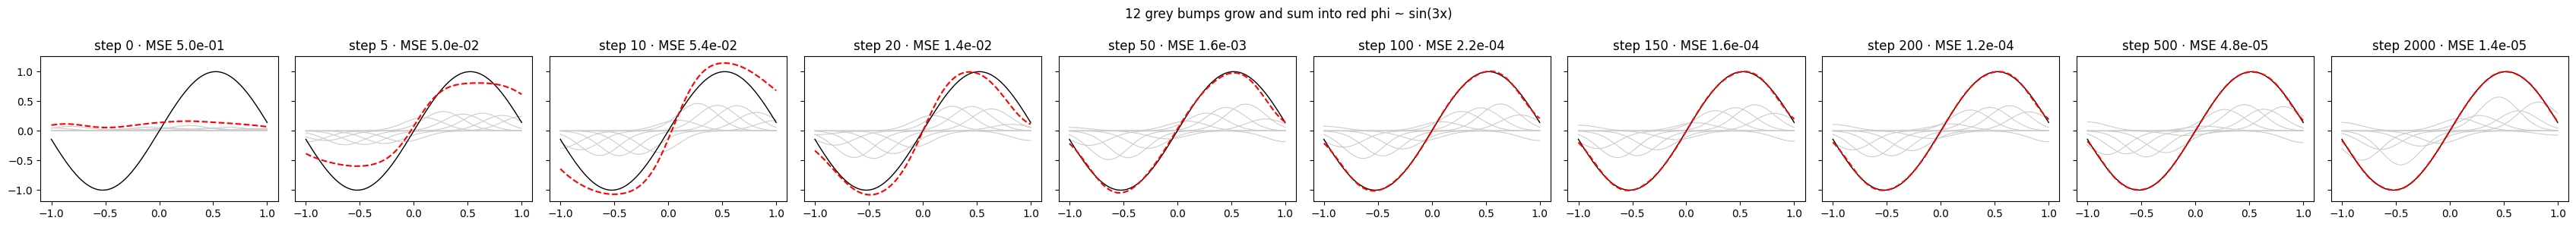

In [4]:
import torch, matplotlib.pyplot as plt

torch.manual_seed(0)
phi = RBFActivation(num_basis=12)
opt = torch.optim.Adam(phi.parameters(), lr=0.05)
x = torch.linspace(-1, 1, 200); y = torch.sin(3*x)

record_at = [0, 5, 10, 20, 50, 100, 150, 200, 500, 2000]      # steps to snapshot
snaps = {}
for step in range(2001):
    if step in record_at:                # snapshot BEFORE this step's update
        with torch.no_grad():
            r = x[:, None] - phi.centers
            bumps = torch.exp(-r**2 / (2*phi.h**2)) * phi.w_rbf   # (200, 12)
            snaps[step] = (bumps.clone(), phi(x).clone(), ((phi(x)-y)**2).mean().item())
    opt.zero_grad(); loss = ((phi(x)-y)**2).mean(); loss.backward(); opt.step()

fig, axes = plt.subplots(1, len(record_at), figsize=(3.4*len(record_at), 3), sharey=True)
for ax, step in zip(axes, record_at):
    bumps, curve, l = snaps[step]
    for b in bumps.T:                    # each of the 12 scaled Gaussians
        ax.plot(x, b, color='0.8', lw=0.8)
    ax.plot(x, y, 'k', lw=1)             # target
    ax.plot(x, curve, 'r--', lw=1.5)     # phi = sum of bumps (+ base)
    ax.set_title(f'step {step} · MSE {l:.1e}')
plt.suptitle('12 grey bumps grow and sum into red phi ~ sin(3x)')
plt.tight_layout(); plt.show()

**Experiment to build intuition:** rerun with `num_basis=3` — the fit gets visibly
worse (too few bumps). That knob *is* the paper's grid size `N`.

➡️ **Promote:** paste your working `RBFActivation` into `src/kan/rbf.py`.
Stuck? See *Milestone 1 → Reference forward* in the guide.

final MSE: 1.375439182993432e-06  (want < 1e-3)


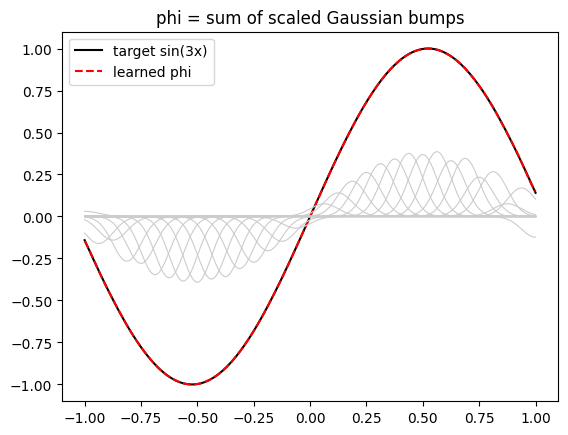

In [5]:
torch.manual_seed(0)
phi = RBFActivation(num_basis=33)
opt = torch.optim.Adam(phi.parameters(), lr=0.05)
x = torch.linspace(-1, 1, 200); y = torch.sin(3*x)
for _ in range(2000):
    opt.zero_grad() # clears buffers previous gradients because backwards function in pytorch accummulates gradients at loss.backward() part so if we don't zero them, it would be grad + grad + ...
    loss = ((phi(x) - y)**2).mean()
    loss.backward() # gradient calculation
    opt.step() # updates parameters

print("final MSE:", loss.item(), " (want < 1e-3)")

plt.plot(x, y, "k", label="target sin(3x)")
plt.plot(x.detach(), phi(x).detach(), "r--", label="learned phi")
# see the decomposition: each bump height * gaussian
with torch.no_grad():
    r = x[:, None] - phi.centers
    bumps = torch.exp(-r**2/(2*phi.h**2)) * phi.w_rbf

for b in bumps.T: # bumps[:, i] is basis function i's weighted contribution across all x
    plt.plot(x, b, color="0.8", lw=0.8)
plt.legend(); plt.title("phi = sum of scaled Gaussian bumps"); plt.show()

---
## Milestone 2 — the AddKAN layer  (Eq. 7; node op = Eq. 10 with n_mu=0)

**Intuition.** Tile the Milestone-1 activation into an `out × in` matrix — one curve
per (output, input) edge — and each output node **sums** its edges:

$$y_{l,i}^{\text{add}}=\sum_{j=1}^{n_l}\phi_{l,i,j}(x_{l,j})$$

**Why these parameters:**

| param | why |
|---|---|
| `in_features, out_features` | the layer's fan-in `n_l` / fan-out `n_{l+1}`; there are `in·out` learnable curves |
| `num_basis` | resolution of each edge curve (as in M1), shared by all edges |
| `grid=(-1,1)` **+ `tanh(x)`** | RBF centers live on `[-1,1]`; you `tanh` the input so *any* real value lands on the grid. Without it, inputs drift off-grid, Gaussians → 0, the layer goes deaf. (This is the paper's alternative to re-gridding.) |

**Shapes** (internalize these — it's where people get stuck):
```
x:(B,in) → tanh → r:(B,in,N) → psi:(B,in,N);  w_rbf:(out,in,N), w_base:(out,in) → y:(B,out)
```

In [6]:
class AddKANLayer(nn.Module):
    # maps in_features -> out_features; each output sums its edge activations
    def __init__(self, in_features, out_features, num_basis=8, grid=(-1., 1.)):
        super().__init__()
        # TODO: centers buffer; self.h; w_rbf (out,in,num_basis); w_base (out,in); base=SiLU()
        
        c = torch.linspace(grid[0], grid[1], num_basis)
        self.register_buffer("centers", c)
        self.h = (grid[1] - grid[0]) / (num_basis - 1)
        
        # Learnable parameters
        self.w_rbf = nn.Parameter(torch.randn(out_features, in_features, num_basis) * 0.1)
        self.w_base = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.base = nn.SiLU()

    def forward(self, x):                                  # (B, in) -> (B, out)
        # TODO:
        #   x = torch.tanh(x)                              # land on the grid
        #   r = x[..., None] - self.centers               # (B, in, N)
        #   psi = torch.exp(-r**2 / (2*self.h**2))        # (B, in, N)
        #   rbf  = torch.einsum("bik,oik->bo", psi, self.w_rbf)          # sum over in & N
        #   base = torch.einsum("bi,oi->bo", self.base(x), self.w_base)  # sum over in
        #   return rbf + base
        
        x = torch.tanh(x) # (B, input_features)
        r = x.unsqueeze(-1) - self.centers # (B, in, N)
        psi = torch.exp(-(r ** 2) / (2 * self.h ** 2)) # (B, in, N)
        rbf = torch.einsum("bik,oik->bo", psi, self.w_rbf)
        base = torch.einsum("bi, oi->bo", self.base(x), self.w_base)

        return rbf + base



**Check** — shapes, parameter count, and a small 2-D fit:

In [7]:
layer = AddKANLayer(4, 7, num_basis=8)
assert layer(torch.randn(5, 4)).shape == (5, 7)
n = sum(p.numel() for p in layer.parameters())
assert n == 7*4*8 + 7*4, n
print("shapes + param count OK:", n, "params")

# fit f(x1,x2) = sin(pi x1) * x2  with a 2-layer AddKAN
torch.manual_seed(0)
net = nn.Sequential(AddKANLayer(2, 8), AddKANLayer(8, 1))
X = torch.rand(512, 2)*2 - 1
Y = (torch.sin(math.pi*X[:, :1]) * X[:, 1:])
opt = torch.optim.Adam(net.parameters(), lr=0.02)
for _ in range(1500):
    opt.zero_grad(); loss = ((net(X) - Y)**2).mean(); loss.backward(); opt.step()
print("2-D fit MSE:", loss.item(), " (want well below 1e-2)")

shapes + param count OK: 252 params
2-D fit MSE: 2.1070702132419683e-05  (want well below 1e-2)


➡️ **Promote** into `src/kan/layers.py`. Reference: *Milestone 2* in the guide.

---
## Milestone 3 — the LeanKAN layer  (Eq. 8–10)

**Why multiplication?** Addition-only KANs are bad at products, but chemistry is
full of them (mass-action rate `k·[A]·[B]`). LeanKAN adds a cheap *multiplication
sublayer* so products are represented directly — a big reason ChemKAN is only ~344
parameters.

$$y_{l,i}^{\text{mult}}=\prod_{j=1}^{n_l^{mu}}\phi_{l,i,j}(x_{l,j}),\qquad
y_{l,i}^{\text{add}}=\sum_{j=n_l^{mu}+1}^{n_l}\phi_{l,i,j}(x_{l,j})$$

**Why `n_mu`:** it's the *multiplication hyperparameter* — how many of the input
nodes get multiplied (the rest are summed). `n_mu=0` ⟹ LeanKAN **is** AddKAN, so
you can write one class.

**Trick:** reuse M2 but stop *before* summing — expose per-edge values
`φ(x)` of shape `(B, out, in)`, then multiply the first `n_mu` columns, add the rest.

⚠️ **Empty-product trap:** `g[..., :0].prod(-1)` is `1`, not `0`. Guard `n_mu==0`.

In [31]:
class LeanKANLayer(nn.Module):
    def __init__(self, in_features, out_features, n_mu=0, num_basis=8, grid=(-1., 1.)):
        super().__init__()
        self.n_mu = n_mu
        self.grid = grid
        self.num_basis = num_basis
        # TODO: same params as AddKANLayer (centers, h, w_rbf, w_base, base)
        
        c = torch.linspace(grid[0], grid[1], num_basis)
        self.register_buffer("centers", c)

        # learnable parameters
        self.w_rbf = nn.Parameter(torch.randn(out_features, in_features, self.num_basis) * 0.1)
        self.w_base = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.base = nn.SiLU()        

    def edge_outputs(self, x):               # (B, in) -> (B, out, in): phi per edge
        # TODO:
        #   x = torch.tanh(x); r = x[...,None]-self.centers; psi = exp(-r**2/(2h**2))
        #   rbf  = einsum("bik,oik->boi", psi, self.w_rbf)
        #   base = einsum("bi,oi->boi", self.base(x), self.w_base)
        #   return rbf + base
        x = torch.tanh(x)
        r = x[..., None] - self.centers
        self.h = (self.grid[1] - self.grid[0]) / (self.num_basis - 1)
        psi = torch.exp(-r**2/(2 * self.h**2))

        rbf = torch.einsum("bik,oik->boi", psi, self.w_rbf)
        base = torch.einsum("bi,oi->boi", self.base(x), self.w_base)
        return rbf + base

    def forward(self, x):
        # TODO:
        #   g = self.edge_outputs(x)                                   # (B, out, in)
        #   mult = g[..., :self.n_mu].prod(dim=-1) if self.n_mu > 0 else 0.0
        #   add  = g[..., self.n_mu:].sum(dim=-1)
        #   return mult + add
        edge_values = self.edge_outputs(x)

        mult = edge_values[..., :self.n_mu].prod(dim=-1) if self.n_mu > 0 else 0.0
        add = edge_values[..., self.n_mu:].sum(dim=-1)
        return mult + add

**Check** — `n_mu=0` ≡ AddKAN, and `n_mu` really multiplies:

In [32]:
torch.manual_seed(0)
lean0 = LeanKANLayer(4, 7, n_mu=0, num_basis=8)
add   = AddKANLayer(4, 7, num_basis=8)
add.load_state_dict(lean0.state_dict())          # identical weights
x = torch.randn(5, 4)
assert torch.allclose(lean0(x), add(x), atol=1e-6), "n_mu=0 should equal AddKAN"

leanM = LeanKANLayer(2, 1, n_mu=2, num_basis=8)
xx = torch.randn(5, 2)
g = leanM.edge_outputs(xx)                        # (5,1,2)
assert torch.allclose(leanM(xx), g[..., 0]*g[..., 1], atol=1e-6), "should be a product"
print("LeanKAN OK: reduces to AddKAN at n_mu=0, and multiplies at n_mu>0")

LeanKAN OK: reduces to AddKAN at n_mu=0, and multiplies at n_mu>0


➡️ **Promote** into `src/kan/layers.py`. Reference: *Milestone 3* in the guide.

---
## Milestone 4 — KAN-ODE: predict the *rate*, then integrate  (Eq. 6)

**Intuition.** Don't predict the state — predict `du/dt = KAN(u)`, the *local
physics*, and let an ODE solver march it forward (like a real kinetic solver).
Gradients flow back **through** the solver — that's the Neural-ODE trick.

**Why the `forward(self, t, u)` signature:** solvers call the RHS as `f(t, u)`.
The chemistry is autonomous (depends only on the state), so `t` is accepted but
ignored — exactly like the KAN-ODEs reference `calDeriv(t, X): return model(X)`.

In [36]:
from torchdiffeq import odeint

class KANODE(nn.Module):
    def __init__(self, kan): 
        super().__init__()
        self.kan = kan

    def forward(self, t, u):
        # TODO: du/dt depends only on u  ->  return self.kan(u)
        return self.kan(u)

def rollout(func, u0, t, method="dopri5"):     # u0:(B,dim), t:(T,) -> (T,B,dim)
    # TODO: return odeint(func, u0, t, method=method)
    return odeint(func, u0, t, method=method)

**Check — overfit ONE biodiesel trajectory** (the classic Neural-ODE smoke test).
Reuse the *train-only* `u_min/u_max` you already stored in the `.npz`
(`common.normalize`) — normalization is what keeps stiff ODEs from blowing up.

0 15.16391372680664
400 0.006172277964651585
800 0.004360452760010958
1200 0.0035625759046524763
1600 0.0024042397271841764


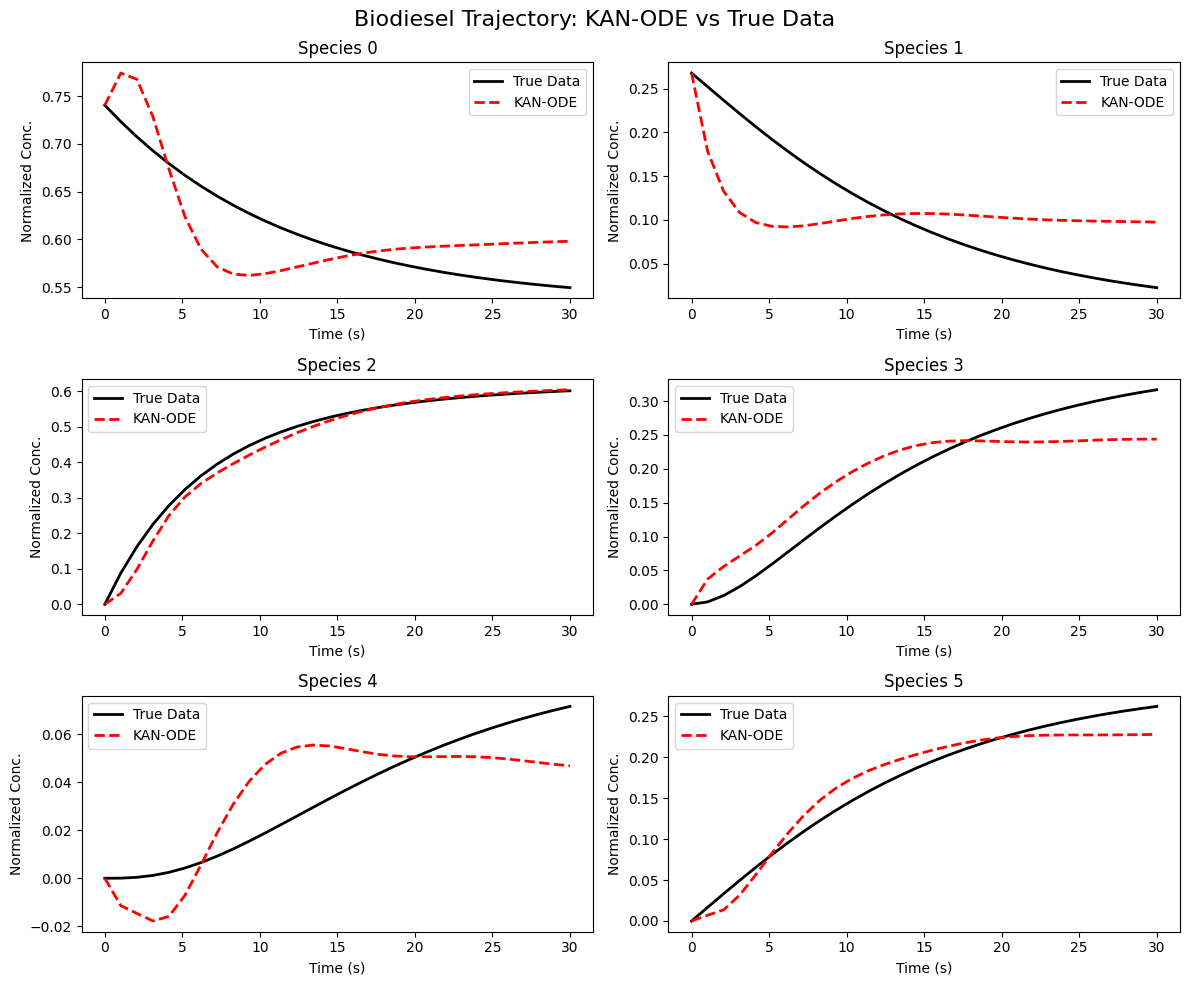

In [38]:
import numpy as np
import matplotlib.pyplot as plt

d = dict(np.load(Path.cwd().parents[0] / "data" / "generated" / "biodiesel.npz"))
t = torch.tensor(d["t"], dtype=torch.float32)                  # (30,)

u = torch.tensor(d["train_states"], dtype=torch.float32)       # (20,30,6)
umin = torch.tensor(d["u_min"], dtype = torch.float32)
umax = torch.tensor(d["u_max"], dtype = torch.float32)
un = (u - umin) / (umax - umin)                                # normalized

torch.manual_seed(0)
func = KANODE(AddKANLayer(6, 6))              # 6 species in/out (isothermal)
opt  = torch.optim.Adam(func.parameters(), lr=2e-3)
case = un[0]; u0 = case[0:1]                  # one trajectory

for step in range(2000):
    opt.zero_grad()
    pred = rollout(func, u0, t)[:, 0, :]
    loss = ((pred - case)**2).mean()
    loss.backward(); opt.step()
    if step % 400 == 0: print(step, loss.item())

# === NEW PLOTTING CODE BELOW ===
# Create a 3x2 grid of subplots (6 total)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten to easily loop through them

for i in range(6):
    # Plot real data (black line)
    axes[i].plot(t, case[:, i], "k", lw=2, label="True Data")
    
    # Plot KAN prediction (red dashed line)
    axes[i].plot(t.detach(), pred.detach()[:, i], "r--", lw=2, label="KAN-ODE")
    
    # Add titles, labels, and legends
    axes[i].set_title(f"Species {i}")
    axes[i].set_xlabel("Time (s)")
    axes[i].set_ylabel("Normalized Conc.")
    axes[i].legend()

plt.suptitle("Biodiesel Trajectory: KAN-ODE vs True Data", fontsize=16)
plt.tight_layout() # Fixes spacing issues so labels don't overlap
plt.show()


If it NaNs, the ODE is too stiff for the explicit solver — normalize time to `[0,1]`
too, and start with biodiesel (not H₂). See the guide's **stiffness** box.

➡️ **Promote** `KANODE`/`rollout` into `src/kan/kanode.py`.

---
## Milestone 4½ and beyond

- **4½ — Lotka–Volterra warm-up** (optional, recommended): reproduce
  [`KAN-ODEs/Lotka-Volterra-Pytorch/predator_prey.py`](https://github.com/DENG-MIT/KAN-ODEs/tree/main/Lotka-Volterra-Pytorch)
  with their layer, then swap in *your* `AddKANLayer`. A known-answer, non-stiff
  check of your plumbing before chemistry.
- **5 — ChemKAN model** → build in `src/chemkan/model.py` (skeleton + docstrings
  already there). Kinetic core (AddKAN∘LeanKAN) + thermo superstructure.
- **6 — two-stage training + Eq. 18 loss** → `src/chemkan/{losses,train}.py`.
- **7 — validate** against the paper (344-param target, noise-robustness, ignition).

Run the layer tests any time: `pytest chemkan/tests/test_layers.py -v`
(they go green as you promote each class into `src/`).